In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
abm_path = os.path.dirname(os.getcwd()) + "/PDAC/sim/outputs/abm/"
pde_path = os.path.dirname(os.getcwd()) + "/PDAC/sim/outputs/pde/"

abm_files = sorted(os.listdir(abm_path))
pde_files = sorted(os.listdir(pde_path))

print(len(abm_files))

280


In [3]:
keys = ['c','t','tcd4','mdsc','mac','fib','apc','vas']
types = ['CANCER','TCELL','TREG','MDSC','MAC','FIB','N/A','VAS']
counts = {}
for i in range(len(keys)):
    counts[keys[i]] = np.zeros(280)

for i in range(280):
    temp = pd.read_csv(abm_path + abm_files[i],header=0)
    ag_type = temp['agent_type'].to_numpy()
    for j in range(len(keys)):
        counts[keys[j]][i] = len(ag_type[ag_type==types[j]])
    
    

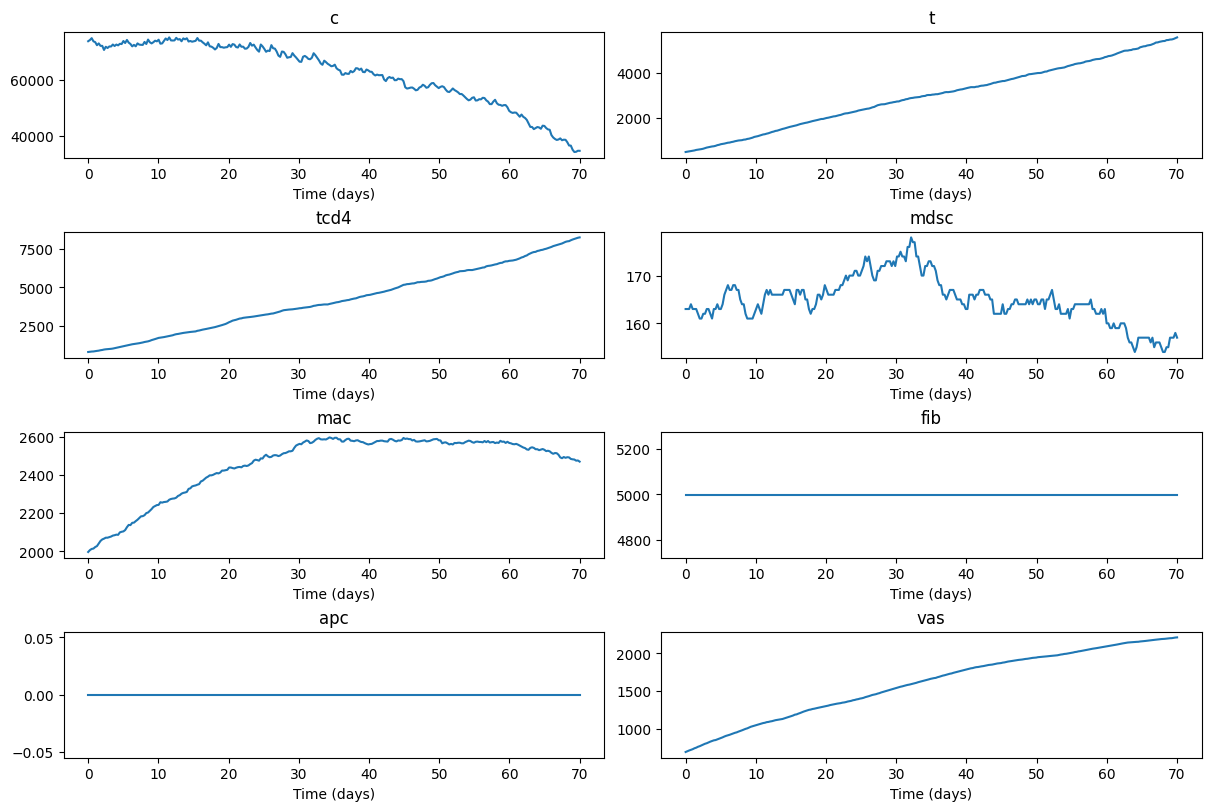

In [4]:
fig,axes = plt.subplots(4,2,figsize=(12,8),layout = 'constrained')
t = np.linspace(0,70,280)
for i,ax in enumerate(axes.reshape(-1)):
    ax.plot(t, counts[keys[i]], label = keys[i])
    ax.set_title(keys[i])
    ax.set_xlabel('Time (days)')

In [5]:
keys = ['IFN','IL2','CCL2','ARGI','NO','TGFB','IL10','IL12','VEGFA','O2']
mol_counts = {}
for i in range(len(keys)):
    mol_counts[keys[i]] = np.zeros(280)

for i in range(280):
    temp = pd.read_csv(pde_path + pde_files[i],header=0)
    for j in range(len(keys)):
        vals = temp[keys[j]].to_numpy()
        mol_counts[keys[j]][i] = np.mean(vals)

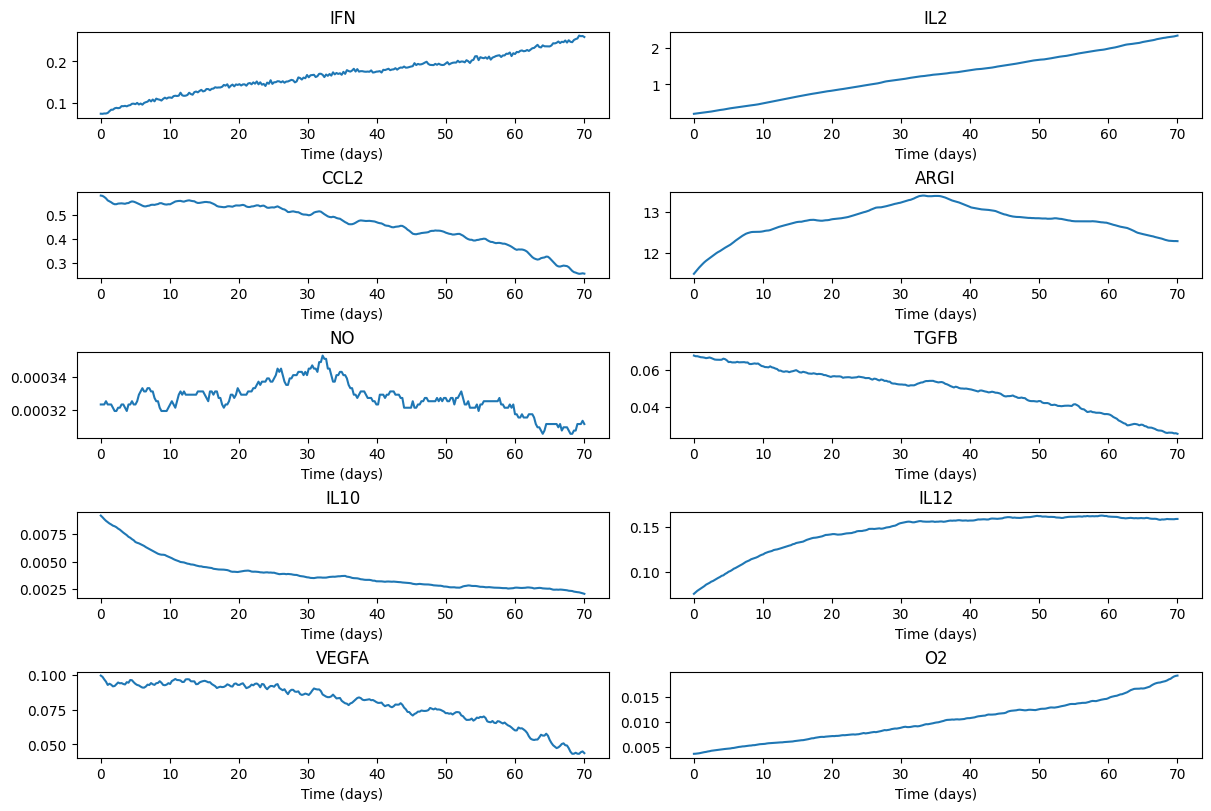

In [6]:
fig,axes = plt.subplots(5,2,figsize=(12,8),layout = 'constrained')
t = np.linspace(0,70,280)
for i,ax in enumerate(axes.reshape(-1)):
    ax.plot(t, mol_counts[keys[i]], label = keys[i])
    ax.set_title(keys[i])
    ax.set_xlabel('Time (days)')